## 📚 Import Needed Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D




## ⏳ Load Dataset

In [3]:
x = np.load('features/X.npy')
y = np.load('features/y.npy')
print(f"Features shape: {x.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (712, 56)
Labels shape: (712,)


## Scale

In [32]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

next step is to reduce these 56 features.

## Dimensionality Reduction: Linear Discriminant Analysis (LDA)

### Why LDA instead of PCA?
Initially, we considered **Principal Component Analysis (PCA)** to reduce the dimensionality of our audio features. However, PCA is an **unsupervised** technique that focuses on maximizing the *variance* in the data, regardless of the class labels. In our case, the directions of maximum variance did not align well with the directions that distinguish the languages, leading to poor separation.

To address this, we switched to **Linear Discriminant Analysis (LDA)**. LDA is a **supervised** technique that specifically aims to:
1.  Maximize the distance **between** different classes (languages).
2.  Minimize the variation **within** each class.

### Determining the Number of Components
LDA has a constraint where the maximum number of components is $C - 1$, where $C$ is the number of classes. Since we have 4 languages, we are limited to a maximum of **3 dimensions**.

We analyzed the Explained Variance Ratio to decide whether to use 2 or 3 components. The cumulative variance of the first two components was analyzed to see if they captured sufficient discriminative information. In the end because the third component contained significant information for separating the languages, we opted to preserve all **3 dimensions** for the clustering stage.

Variance explained by 2 components: 0.40


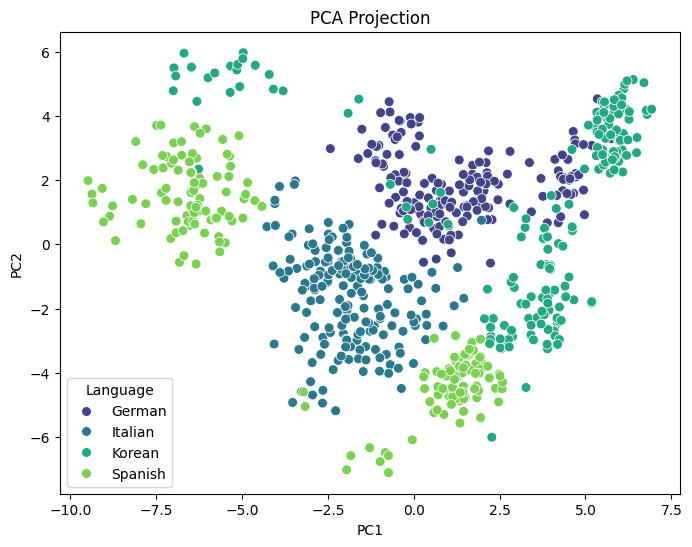

In [33]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(x)

print(f"Variance explained by 2 components: {np.sum(pca_2d.explained_variance_ratio_):.2f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y, palette='viridis', s=50)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title='Language')
plt.show()

Variance per component: [0.47663967 0.3445475  0.17881283]
Cumulative Variance with 2 components: 82.12%
Cumulative Variance with 3 components: 100.00%


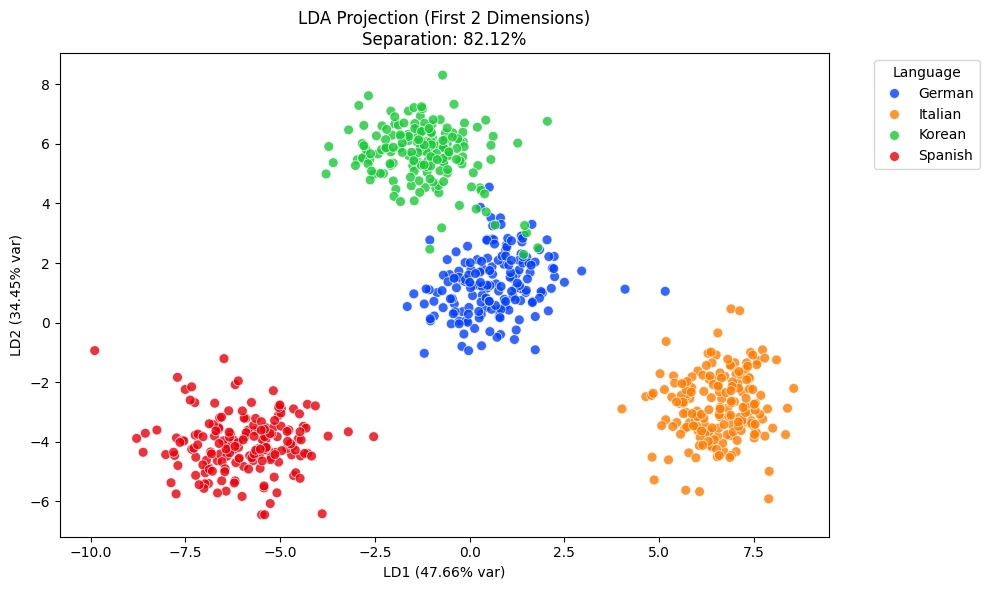

In [34]:
lda = LDA(n_components=None)
X_lda = lda.fit_transform(x, y)


variance_ratios = lda.explained_variance_ratio_

print("Variance per component:", variance_ratios)
print(f"Cumulative Variance with 2 components: {sum(variance_ratios[:2]):.2%}")
print(f"Cumulative Variance with 3 components: {sum(variance_ratios[:3]):.2%}")


plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, palette='bright', s=50, alpha=0.8)
plt.title(f'LDA Projection (First 2 Dimensions)\nSeparation: {sum(variance_ratios[:2]):.2%}')
plt.xlabel(f'LD1 ({variance_ratios[0]:.2%} var)')
plt.ylabel(f'LD2 ({variance_ratios[1]:.2%} var)')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## K-Means

K-Means is a centroid-based algorithm that partitions the data into $K$ clusters by minimizing the variance within each cluster.

### Finding the Optimal K (Elbow Method)
Although we know the ground truth contains **4 languages**, it is crucial to verify if the data *naturally* forms 4 distinct groups in our LDA-transformed feature space. We used the **Elbow Method**, plotting the **Inertia** (sum of squared distances to the nearest cluster center) against different values of $K$.
as expected we see a bend in the curve at $K=4$ and ran K-Means with $K=4$ on the 3D LDA features.

### Evaluation
  K-Means Silhouette Score: 0.7572

  In the end of this notebook, we calculated the purity.

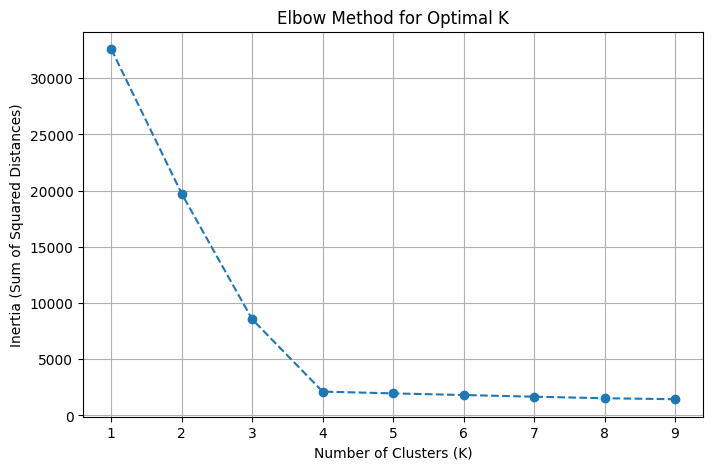

In [35]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_lda)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

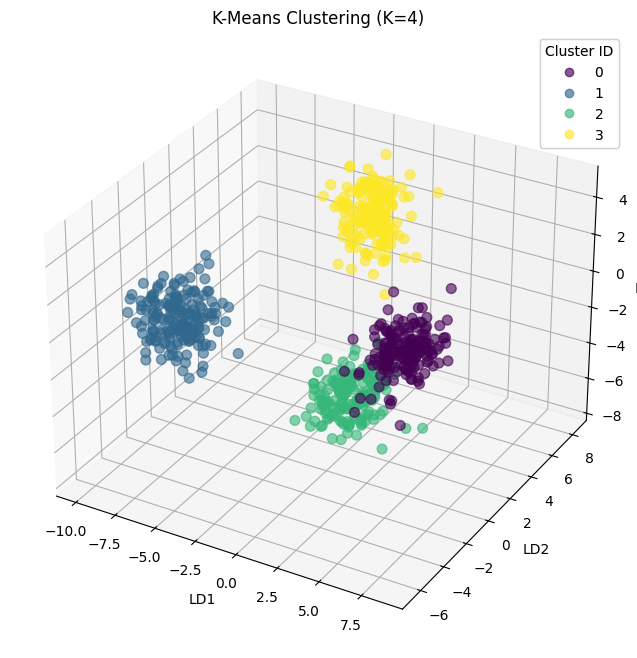

In [36]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_lda)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_lda[:, 0],
    X_lda[:, 1],
    X_lda[:, 2],
    c=kmeans_labels,
    cmap='viridis',
    s=50,
    alpha=0.6
)

ax.set_title(f'K-Means Clustering (K={optimal_k})')
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('LD3')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster ID")
ax.add_artist(legend1)

plt.show()

In [37]:
kmeans_sil = silhouette_score(X_lda, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_sil:.4f}")

K-Means Silhouette Score: 0.7572


## DBSCAN

Unlike K-Means, **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** does not require us to specify the number of clusters beforehand. Instead, it groups together points that are closely packed (high density) and marks points in low-density regions as **outliers (Noise, labeled as -1)**.

This is particularly useful for audio data, as it allows us to identify "impure" or ambiguous samples that do not clearly belong to any specific language profile.

### Parameter Tuning
DBSCAN requires two key parameters:
1.  **`min_samples`**: Set to 6 (following the rule of thumb $2 \times \text{Dimensions}$).
2.  **`eps` (Epsilon)**: The maximum distance between two samples for one to be considered as in the neighborhood of the other.

To find the optimal `eps`, we utilized the **K-Distance Graph** (nearest neighbor distances). We sorted the distance of every point to its 5th nearest neighbor and looked for the "knee" (or elbow) of the curve. The y-value at this knee point represents the distance threshold where points start to drift too far apart to be considered a cluster, giving us our optimal epsilon.

### Evaluation
  DBSCAN Silhouette Score: 0.6525

  In the end of this notebook, we calculated the purity.

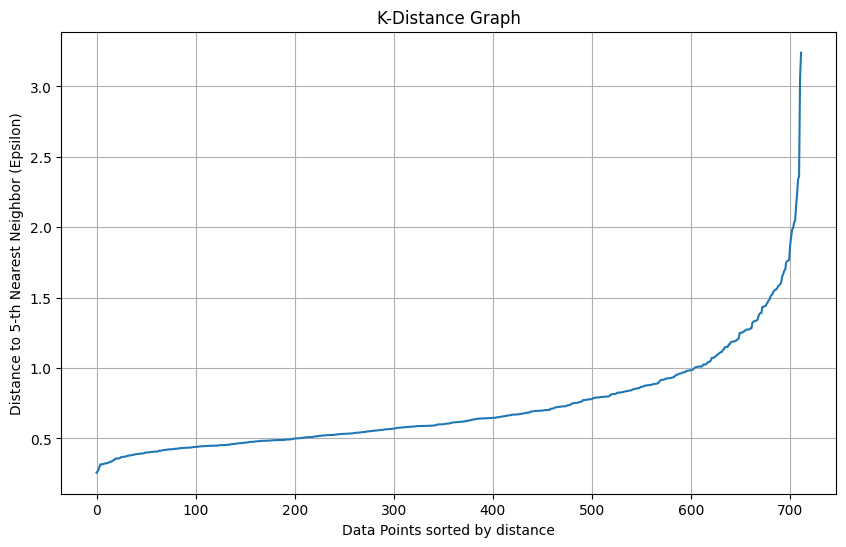

In [38]:
dim = 3
min_samples = 2 * dim
k = min_samples - 1
nbrs = NearestNeighbors(n_neighbors=k).fit(X_lda)
distances, indices = nbrs.kneighbors(X_lda)

sorted_distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title('K-Distance Graph')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'Distance to {k}-th Nearest Neighbor (Epsilon)')
plt.grid(True)
plt.show()

Seeing the above graph, we decided on eps = 1

In [39]:

eps = 1
min_samples = 6

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_lda)


print(f"Number of clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Number of noise points: {list(dbscan_labels).count(-1)}")

Number of clusters found: 4
Number of noise points: 60


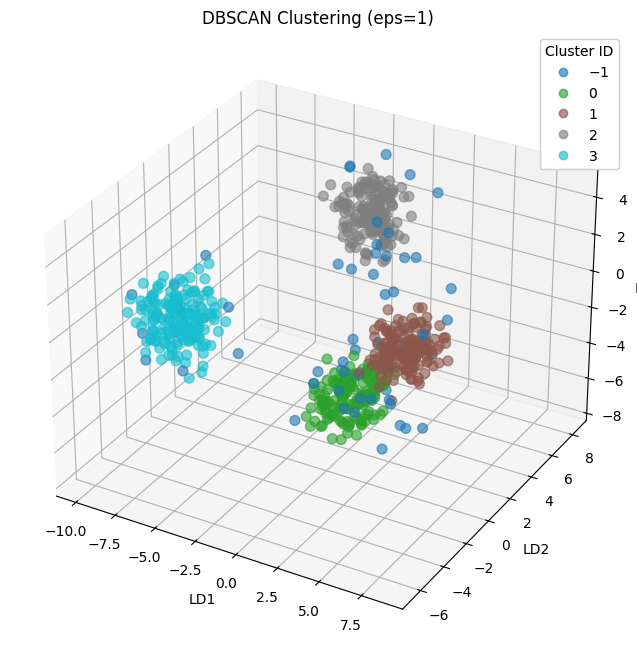

In [40]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_lda[:, 0],
    X_lda[:, 1],
    X_lda[:, 2],
    c=dbscan_labels,
    cmap='tab10',
    s=50,
    alpha=0.6
)

ax.set_title(f'DBSCAN Clustering (eps={eps})')
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('LD3')

legend = ax.legend(*scatter.legend_elements(), title="Cluster ID")
ax.add_artist(legend)

plt.show()

In [41]:
dbscan_sil = silhouette_score(X_lda, dbscan_labels)
print(f"DBSCAN Silhouette Score: {dbscan_sil:.4f}")

DBSCAN Silhouette Score: 0.6525


## 5. Visualization and Final Analysis

### t-SNE Visualization
To visually assess the quality of our clustering, we employed **t-SNE (t-Distributed Stochastic Neighbor Embedding)**. While LDA is a linear method used for *feature selection*, t-SNE is a non-linear technique excellent for *visualization*. It maps our high-dimensional data onto a 2D plane while trying to preserve local neighborhoods.

We generated side-by-side plots to compare:
1.  **Ground Truth:** The actual languages.
2.  **K-Means:** How the centroid-based algorithm divided the space.
3.  **DBSCAN:** How the density-based algorithm handled the data and identified noise.



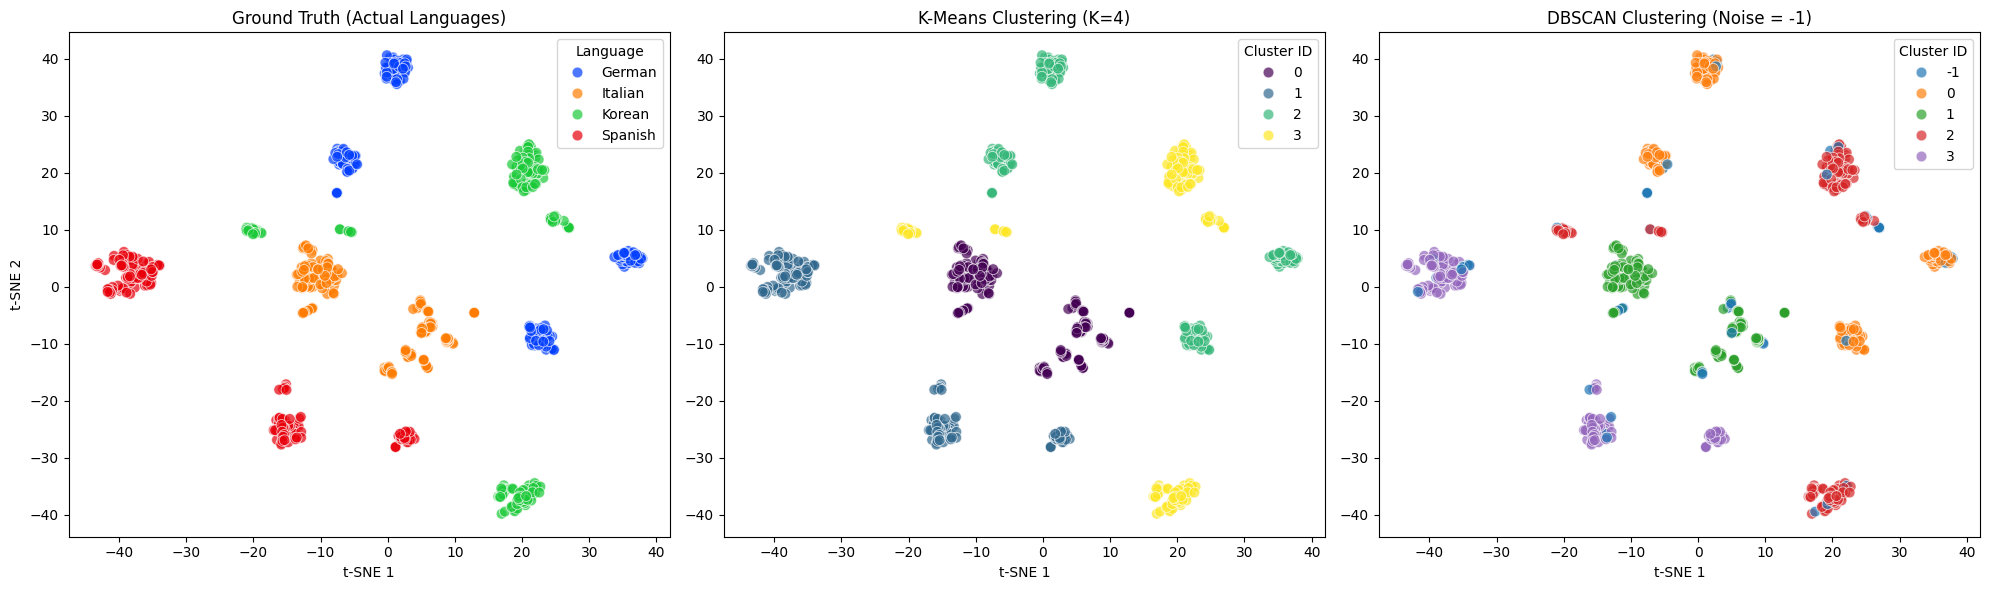

In [42]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(x)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y,
    palette='bright',
    s=60, alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Ground Truth (Actual Languages)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(title='Language')

sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=kmeans_labels,
    palette='viridis',
    s=60, alpha=0.7,
    ax=axes[1]
)
axes[1].set_title(f'K-Means Clustering (K={len(set(kmeans_labels))})')
axes[1].set_xlabel('t-SNE 1')
axes[1].legend(title='Cluster ID')

sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=dbscan_labels,
    palette='tab10',
    s=60, alpha=0.7,
    ax=axes[2]
)
axes[2].set_title(f'DBSCAN Clustering (Noise = -1)')
axes[2].set_xlabel('t-SNE 1')
axes[2].legend(title='Cluster ID')

plt.tight_layout()
plt.show()

### Cluster Composition and Purity
To interpret the results beyond simple metrics, we analyzed the **Purity** of each cluster. By cross-referencing the cluster IDs with the true labels, we determined the dominant language in each cluster. This helps us understand which languages are easily distinguishable (high purity) and which ones are acoustically similar and prone to confusion (mixed clusters).

In [43]:
import pandas as pd
import numpy as np

lang_map = {0: 'Lang_0', 1: 'Lang_1', 2: 'Lang_2', 3: 'Lang_3'}

df_y = [lang_map.get(i, f"Lang_{i}") for i in y]

def analyze_composition(true_labels, cluster_labels, algorithm_name):
    print(f"\n{algorithm_name} Cluster Composition")

    df = pd.DataFrame({'Ground Truth': true_labels, 'Cluster ID': cluster_labels})

    crosstab = pd.crosstab(df['Cluster ID'], df['Ground Truth'])

    print(crosstab)


    majority_sum = 0
    total_samples = len(true_labels)

    print("\nDetailed Purity per Cluster:")
    for cluster in crosstab.index:
        if cluster == -1:
            print(f"  Cluster -1 (Noise): Ignored in purity calculation")
            continue

        row = crosstab.loc[cluster]
        max_count = row.max()
        majority_lang = row.idxmax()
        cluster_size = row.sum()

        majority_sum += max_count

        print(f"  Cluster {cluster}: {max_count}/{cluster_size} points are {majority_lang} "
              f"({max_count/cluster_size:.1%} Pure)")

    purity = majority_sum / total_samples
    print(f"\n Overall {algorithm_name} Purity: {purity:.4f}")

analyze_composition(df_y, kmeans_labels, "K-Means")
analyze_composition(df_y, dbscan_labels, "DBSCAN")


K-Means Cluster Composition
Ground Truth  Lang_German  Lang_Italian  Lang_Korean  Lang_Spanish
Cluster ID                                                        
0                       0           180            0             0
1                       0             0            0           180
2                     172             0            0             0
3                       0             0          180             0

Detailed Purity per Cluster:
  Cluster 0: 180/180 points are Lang_Italian (100.0% Pure)
  Cluster 1: 180/180 points are Lang_Spanish (100.0% Pure)
  Cluster 2: 172/172 points are Lang_German (100.0% Pure)
  Cluster 3: 180/180 points are Lang_Korean (100.0% Pure)

 Overall K-Means Purity: 1.0000

DBSCAN Cluster Composition
Ground Truth  Lang_German  Lang_Italian  Lang_Korean  Lang_Spanish
Cluster ID                                                        
-1                     13            16           17            14
 0                    159             0    